In [1]:
import yaml
import numpy as np

# 读取 YAML 文件
with open('total.yaml', 'r') as file:
    data = yaml.safe_load(file)
with open('total2.yaml', 'r') as file:
    data2 = yaml.safe_load(file)
with open('total3.yaml', 'r') as file:
    data3 = yaml.safe_load(file)

# 定义一个函数来处理数据
def calculate_metrics(data):
    result = {}
    
    # 遍历每个数据集
    for dataset, networks in data.items():
        result[dataset] = {}
        
        # 遍历每种网络
        for network, methods in networks.items():
            # 获取TGL数据并计算TGL方法的值
            tgl_data = methods['TGL']
            tgl_sum = sum(tgl_data.values())  # 将TGL的所有数值加总

            mspipe_data = methods['MSPipe']
            ms_pipe_value = max(mspipe_data['GPU Gather'] + mspipe_data['GPU Updater'] +mspipe_data['Linear'] + mspipe_data['Attention'],
                                mspipe_data['Sample'] + mspipe_data['CPU Gather'] + mspipe_data['memcpyH2D'] + mspipe_data['Mailbox']) + mspipe_data['memcpyD2H']
            # 获取UNITY数据并根据规则计算UNITY方法的值
            unity_data = methods['UNITY']
            unity_value = min(
                max(unity_data['Sample'] + unity_data['Mailbox'] + unity_data['Linear']+unity_data['GPU Updater'],
                    unity_data['GPU Updater'] + unity_data['Linear'] + unity_data['Attention']),
                max(unity_data['Sample'] + unity_data['Linear'] + unity_data['GPU Updater'],
                    unity_data['GPU Updater'] + unity_data['Mailbox'] + unity_data['Linear'] + unity_data['Attention']),
                max(unity_data['Sample'] + unity_data['Linear'] ,
                    unity_data['GPU Updater']*1.3 + unity_data['Mailbox'] + unity_data['Linear'] + unity_data['Attention']),
            )

            tglite_data = methods['TGLite']
            tglite_sum = sum(tglite_data.values())  # 将TGL的所有数值加总
            # 计算MSPipe方法: TGL - Sample
            
            
            result[dataset][network] = {
                'TGL': 1000 / tgl_sum,
                'MSPipe': 1000 / ms_pipe_value,
                'UNITY':  1000 / unity_value,
                'TGLite':  1000 / tglite_sum * 1.05
            }
    
    return result

def calculate_metrics2(data):
    result = {}
    
    # 遍历每个数据集
    for dataset, networks in data.items():
        result[dataset] = {}
        
        # 遍历每种网络
        for network, methods in networks.items():
            # 获取TGL数据并计算TGL方法的值
            tgl_data = methods['TGL']
            tgl_sum = sum(tgl_data.values())  # 将TGL的所有数值加总

            mspipe_data = methods['MSPipe']
            ms_pipe_value = sum(mspipe_data.values())
            # 获取UNITY数据并根据规则计算UNITY方法的值
            unity_data = methods['UNITY']
            unity_value = min(
                max(unity_data['Sample'] + unity_data['Mailbox'] + unity_data['Linear']+unity_data['GPU Updater'],
                    unity_data['GPU Updater'] + unity_data['Linear'] + unity_data['Attention']),
                max(unity_data['Sample'] + unity_data['Linear'] + unity_data['GPU Updater'],
                    unity_data['GPU Updater'] + unity_data['Mailbox'] + unity_data['Linear'] + unity_data['Attention'])
            )
            
            # 计算MSPipe方法: TGL - Sample
            tglite_data = methods['TGLite']
            tglite_sum = sum(tglite_data.values())  # 将TGL的所有数值加总
            
            result[dataset][network] = {
                'TGL': 1000 / tgl_sum,
                'MSPipe': 1000 / ms_pipe_value,
                'UNITY':  1000 / unity_value,
                'TGLite':  1000 / tglite_sum * 1.04
            }
    
    return result



def transform_data(data3):
    metrics3 = {}

    # 遍历原始数据结构并转换
    for dataset, networks in data3.items():
        metrics3[dataset] = {}
        for network, values in networks.items():
            metrics3[dataset][network] = {
                'TGL': values['TGL'],
                'MSPipe': values['MSPipe'],
                'UNITY': values['UNITY'],
                'TGLite': values['TGLite']
            }

    return metrics3
                
# 处理数据
metrics = calculate_metrics(data)
metrics2 = calculate_metrics(data2)
metrics3 = transform_data(data3)

m = calculate_metrics2(data)


def calculate_metrics_with_inverse(metrics1, metrics3):
    result_metrics = {}

    # 遍历 metrics3 和 metrics1 中的每个数据集
    for dataset in metrics3.keys():
        result_metrics[dataset] = {}

        # 确保 metrics1 和 metrics3 中有相同的网络名称
        for network in metrics3[dataset].keys():
            values1 = metrics1.get(dataset, {}).get(network, {})
            values3 = metrics3.get(dataset, {}).get(network, {})

            # 计算 TGL 和 MSPipe
            if values1 and values3:
                tgl_result = 1000 / values1['TGL'] + values3['TGL']
                mspipe_result = 1000 / values1['MSPipe'] + values3['MSPipe']
                unity_result = max(1000 / values1['UNITY'] + values3['UNITY'] / 10, values3['UNITY'])  # UNITY 使用不同的计算方式
                tglite_result = 1000 / values1['TGLite'] + values3['TGLite']

                result_metrics[dataset][network] = {
                    'TGL': tgl_result,
                    'MSPipe': mspipe_result,
                    'UNITY': unity_result,
                    'TGLite': tglite_result
                }

    return result_metrics

m3 = calculate_metrics_with_inverse(m, metrics3)


for dataset, networks in metrics.items():
    print(f"Dataset: {dataset}")
    for network, values in networks.items():
        print(f"  Network: {network}")
        print(f"    TGL: {1000/values['TGL']}")
        print(f"    MSPipe: {1000/values['MSPipe']}")
        print(f"    UNITY: {1000/values['UNITY']}")
        print(f"    TGLite: {1000/values['TGLite']}")

unity_tgl_ratio = {}
unity_mspipe_ratio = {}
unity_tglite_ratio = {}
unity_sota_ratio = {}

for dataset, networks in m3.items():
    unity_tgl_ratio[dataset] = {}
    unity_mspipe_ratio[dataset] = {}
    unity_tglite_ratio[dataset] = {}
    unity_sota_ratio[dataset] = {}
    for network, values in networks.items():
        unity_tgl_ratio[dataset][network] = values['TGL'] / values['UNITY'] 
        unity_mspipe_ratio[dataset][network] = values['UNITY'] / values['MSPipe']
        unity_tglite_ratio[dataset][network] = values['UNITY'] / values['TGLite']
        unity_sota_ratio[dataset][network] = min(values['UNITY'] / values['TGL'], values['UNITY'] / values['MSPipe'], values['UNITY'] / values['TGLite'])
        
        

# 打印结果
for dataset, networks in unity_tgl_ratio.items():
    print(f"Dataset: {dataset}")
    for network, ratio in networks.items():
        print(f"  Network: {network}")
        print(f"    UNITY/SOTA Ratio: {ratio:.4f}")


Dataset: WIKITALK
  Network: APAN
    TGL: 23.200000000000003
    MSPipe: 25.8
    UNITY: 9.9
    TGLite: 21.142857142857142
  Network: DySAT
    TGL: 37.1
    MSPipe: 31.9
    UNITY: 22.4
    TGLite: 33.14285714285714
  Network: TGAT
    TGL: 39.5
    MSPipe: 34.3
    UNITY: 23.3
    TGLite: 35.80952380952381
  Network: JODIE
    TGL: 10.100000000000001
    MSPipe: 10.3
    UNITY: 6.3
    TGLite: 9.428571428571429
  Network: TGN
    TGL: 24.9
    MSPipe: 21.5
    UNITY: 13.3
    TGLite: 23.238095238095237
Dataset: ROADCA
  Network: APAN
    TGL: 29.999999999999996
    MSPipe: 27.4
    UNITY: 12.8
    TGLite: 28.19047619047619
  Network: DySAT
    TGL: 99.7
    MSPipe: 96.5
    UNITY: 61.79999999999999
    TGLite: 91.42857142857143
  Network: TGAT
    TGL: 111.79999999999998
    MSPipe: 108.60000000000001
    UNITY: 70.9
    TGLite: 106.28571428571429
  Network: JODIE
    TGL: 16.0
    MSPipe: 21.9
    UNITY: 8.7
    TGLite: 15.04761904761905
  Network: TGN
    TGL: 52.099999999999994


/tmp/ipykernel_80928/2162399338.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


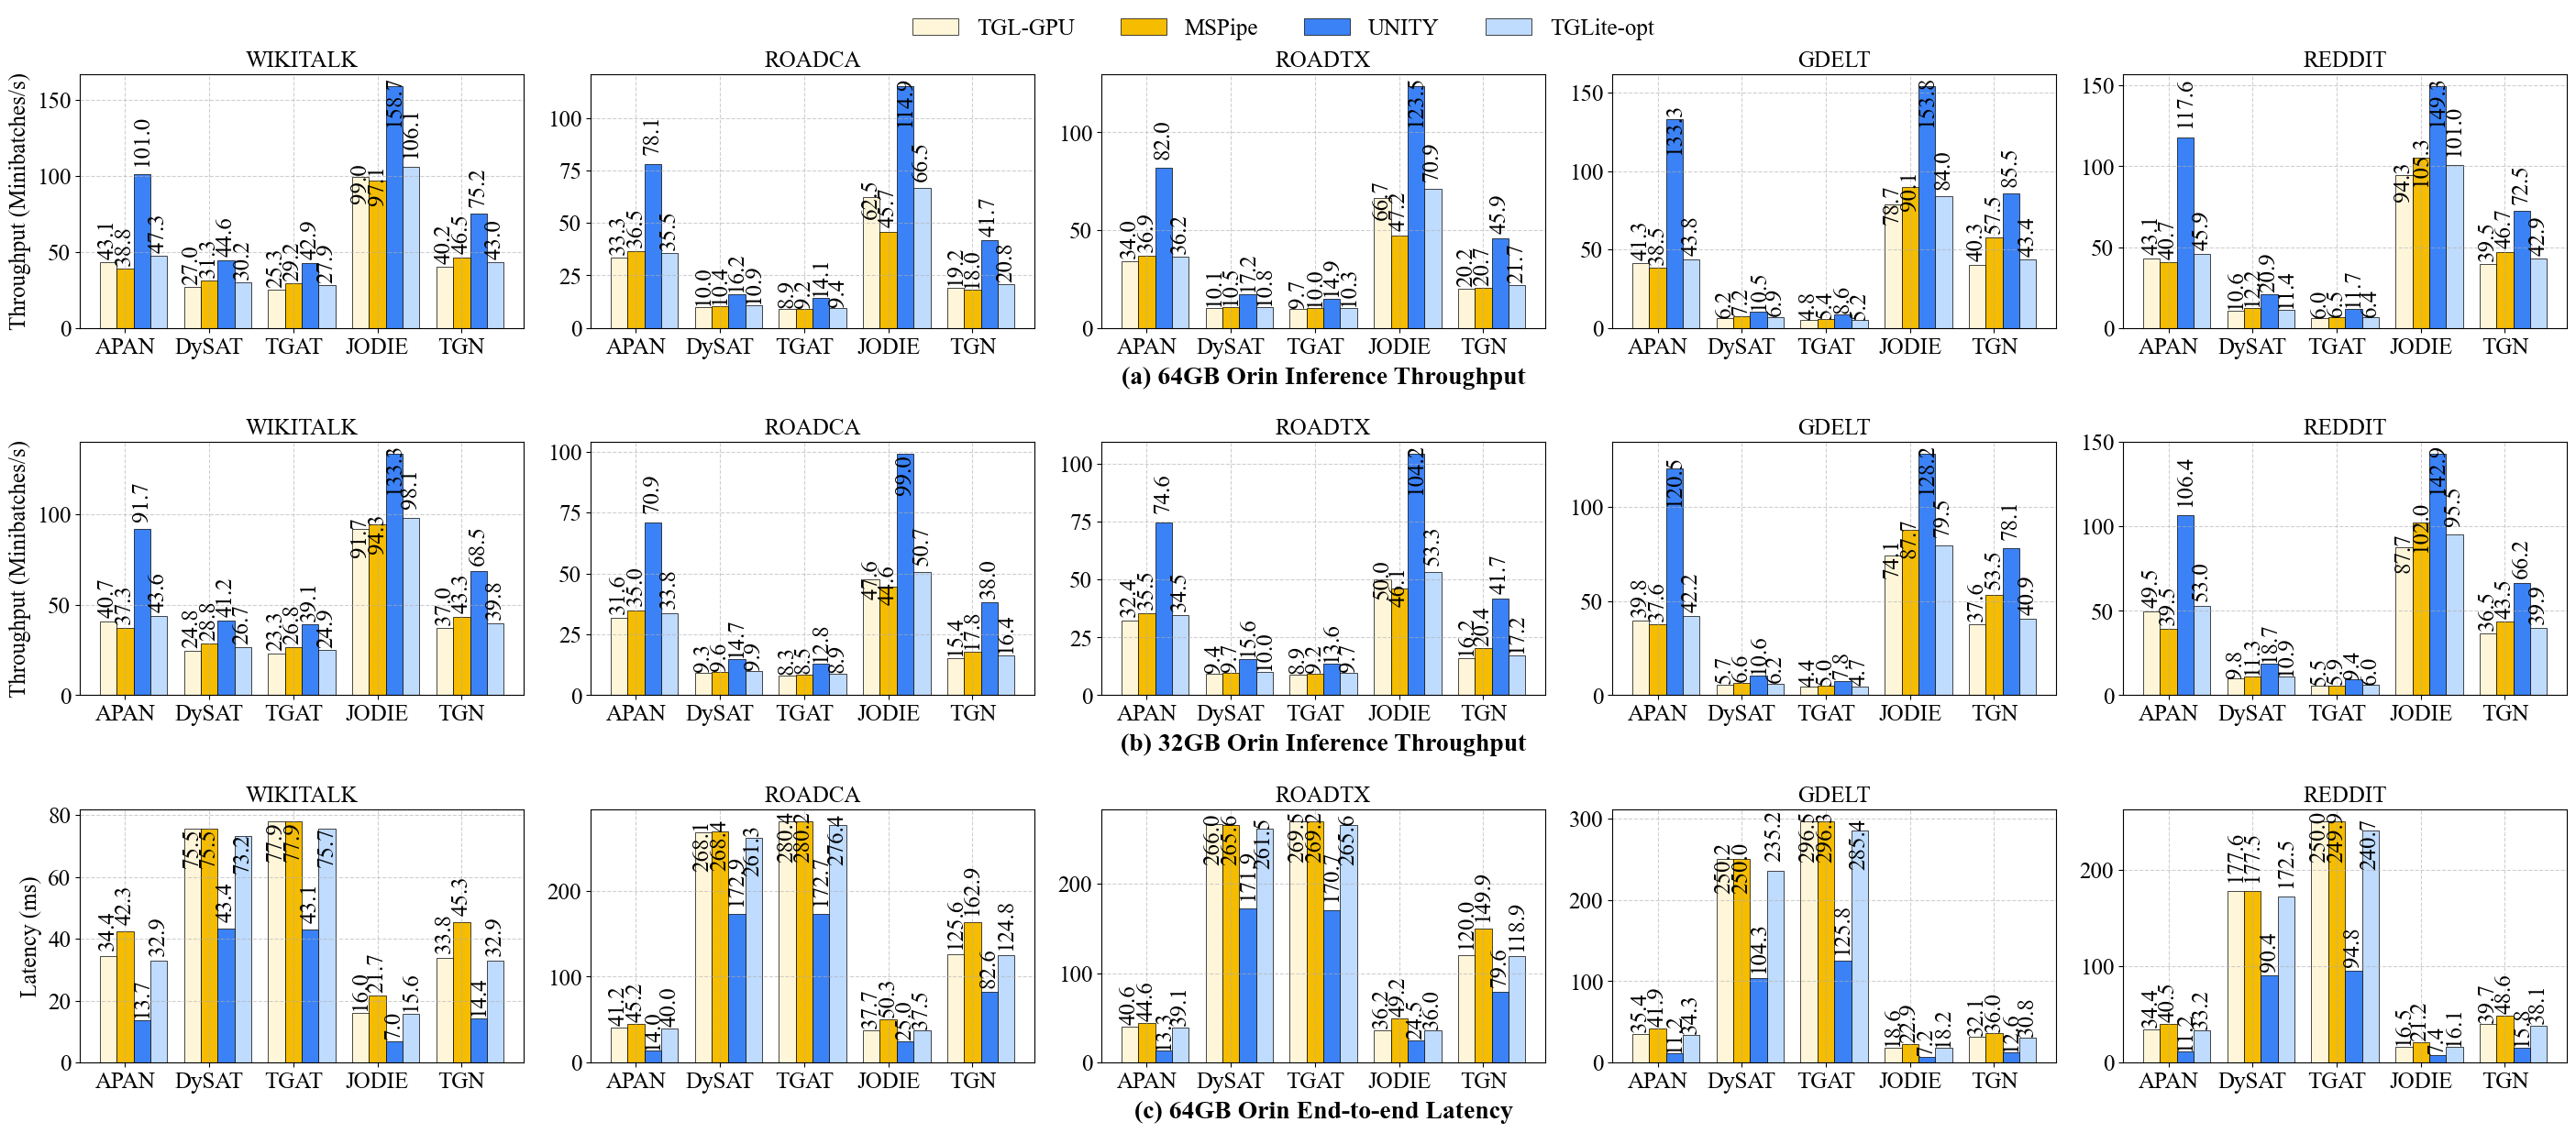

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random
import yaml
from matplotlib import gridspec

plt.rcParams['font.family'] = 'Times New Roman'

plt.rc('font', size=18)
plt.rc('axes', titlesize=18)

# 配置参数
hardware_configs = ['(a) 64GB Orin Inference Throughput', '(b) 32GB Orin Inference Throughput', '(c) 64GB Orin End-to-end Latency']
datasets = ['WIKITALK', 'ROADCA', 'ROADTX', 'GDELT', 'REDDIT']
algorithms = ['APAN', 'DySAT', 'TGAT', 'JODIE', 'TGN']
baseline_labels = ['TGL-GPU', 'MSPipe', 'UNITY', 'TGLite']


yaml_files = ["summary_data_64GB.yaml", "summary_data_32GB.yaml", "summary_data_single.yaml"]

# 定义实验名称，按照 (a) exp, (b) exp, (c) exp 的顺序
exp_names = ["(a) 64GB Orin Inference Throughput", "(b) 32GB Orin Inference Throughput", "(c) 64GB Orin End-to-end Latency"]

data = {}

# 依次读取 YAML 文件，并填充数据
for exp_name, yaml_file in zip(exp_names, yaml_files):
    with open(yaml_file, "r") as file:
        yaml_data = yaml.safe_load(file)  # 读取 YAML 数据
    
    formatted_data = {}
    for dataset, models in yaml_data.items():
        formatted_data[dataset] = {}
        for model, values in models.items():
            # 提取 TGL, TGLite, UniTGL 三个值，并存入列表
            if yaml_file == "summary_data_64GB.yaml":
                # formatted_data[dataset][model] = [1/values["TGL"], 1/values["TGLite"], 1/values["UniTGL"]]
                formatted_data[dataset][model] = [metrics[dataset][model]["TGL"], metrics[dataset][model]["MSPipe"], metrics[dataset][model]["UNITY"], metrics[dataset][model]["TGLite"]]
            elif yaml_file == "summary_data_32GB.yaml":
                formatted_data[dataset][model] = [metrics2[dataset][model]["TGL"], metrics2[dataset][model]["MSPipe"], metrics2[dataset][model]["UNITY"], metrics2[dataset][model]["TGLite"]]
            else:
                formatted_data[dataset][model] = [m3[dataset][model]["TGL"], m3[dataset][model]["MSPipe"], m3[dataset][model]["UNITY"], m3[dataset][model]["TGLite"]]
    # print(formatted_data)
    data[exp_name] = formatted_data

# print(data)

# 创建总图
fig = plt.figure(figsize=(35, 14))
# 外层 GridSpec：3 行 1 列
outer_gs = gridspec.GridSpec(3, 1, hspace=0.45)

# 颜色配置
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # baseline1, baseline2, ours
colors = ['#FFF6da','#F5BC00','#3B82F6', '#BFDBFE']
import mycolors
# colors = [mycolors.LADDER_ORDER.LIGHT_GRAY, mycolors.MALOPE.PURPLE, mycolors.LADDER_ORDER.LIGHT_GREEN]

# 遍历每个硬件配置（每行）
for row_idx, hardware in enumerate(hardware_configs):
    # 内层 GridSpec：每行 1×5 布局，wspace 调整子图之间间距
    inner_gs = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=outer_gs[row_idx], wspace=0.15)
    
    # 在每行的左侧上方添加硬件配置标题（通过在该行对应的区域上绘制文本）
    # outer_pos = outer_gs[row_idx].get_position(fig)
    # fig.text(outer_pos.x0, outer_pos.y1 + 0.01, hardware, fontsize=14, fontweight='bold')
    
    outer_pos = outer_gs[row_idx].get_position(fig)
    fig.text((outer_pos.x0 + outer_pos.x1) / 2, outer_pos.y0 - 0.03, hardware,
         ha='center', va='top', fontsize=20, fontweight='bold')


    # 遍历每个数据集（每个子图）
    for col_idx, dataset in enumerate(datasets):
        ax = fig.add_subplot(inner_gs[col_idx])
        
        # 设置x轴位置（为每个算法分配基础位置）
        x_base = np.arange(len(algorithms))  # [0,1,2,3,4]
        bar_width = 0.2

        # 绘制每个算法的三个baseline
        for baseline_idx in range(4):
            # 计算每个bar的水平位置
            x_offset = x_base + (baseline_idx - 1) * bar_width
            values = [data[hardware][dataset][algo][baseline_idx] for algo in algorithms]
            
            # 绘制柱状图
            bars = ax.bar(x_offset, values, width=bar_width,              
                            edgecolor='black', 
                            linewidth=0.5, 
                            alpha=1,
                            color=colors[baseline_idx],
                            label=baseline_labels[baseline_idx] if col_idx == 0 else "")
            
            # 添加数据标签
            for bar in bars:
                height = bar.get_height()
                label_height = height * 1.05
                if label_height > ax.get_ylim()[1]*0.82:  # 如果超出了 y 轴范围
                    label_height = height * 0.83  # 将标签放在柱子顶端的下方
                
                ax.text(bar.get_x() + bar.get_width()/2., label_height,
                        f'{height:.1f}', ha='center', va='bottom', fontsize=18, rotation=90)

        # 设置子图属性
        ax.set_title(dataset, fontsize=18)  # 每个小子图的标题为数据集名称
        ax.set_xticks(x_base)
        ax.set_xticklabels(algorithms, rotation=0, ha='center', fontsize=18)
        # ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', alpha=0.6)

        # 坐标轴标签
        if col_idx == 0 and row_idx == 0:
            ax.set_ylabel('Throughput (Minibatches/s)', fontsize=18)
        if col_idx == 0 and row_idx == 1:
            ax.set_ylabel('Throughput (Minibatches/s)', fontsize=18)
        if col_idx == 0 and row_idx == 2:
            ax.set_ylabel('Latency (ms)', fontsize=18)
        # if row_idx == 2:
        #     ax.set_xlabel('Algorithms')

# 添加统一图例（取第一行第一个子图的图例即可）
handles, labels = fig.axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center',
           ncol=4, bbox_to_anchor=(0.5, 0.94),
           fontsize=18, frameon=False)

# plt.tight_layout(rect=[0, 0, 1, 0.95])
# 调整布局
plt.tight_layout()

# 保存图像
plt.savefig('exp1.pdf', bbox_inches='tight')
plt.show()
